<a href="https://colab.research.google.com/github/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Proyecto_Final_263166.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final**

**Nombre:** Laila Montserrat Bulhosen Ramos **Matrícula**: 263166

**Docente:** Dr. Rogelio Florencia Juarez

**Materia:** Procesamiento de Lenguaje Natural



**Link Github:** [Proyecto_Final_263166](https://github.com/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Proyecto_Final_263166.ipynb)

**Fecha:** Mayor 2026


### **Carga de dataset**


In [1]:
### Drive connection

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [61]:
dataset = pd.read_csv('/content/drive/MyDrive/Procesamiento Lenguaje Natural/Dataset.csv')

In [62]:
display(dataset.head(5))

,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### **EDA**

**Descripción**

In [63]:
print('Tamaño del dataset:', dataset.shape)

print('\nDescibe del dataset:')
dataset.describe()


Tamaño del dataset: (6661, 2)

Descibe del dataset:


,phrase,prompt
count,6661,6661
unique,706,25
top,When I stand up too quickly I start to feel di...,Acne
freq,35,328


In [64]:
print('\nInformación del dataset:\n')
dataset.info()


Información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6661 entries, 0 to 6660
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   phrase  6661 non-null   object
 1   prompt  6661 non-null   object
dtypes: object(2)
memory usage: 104.2+ KB


**Distribución de clases**

In [66]:
### Clases de síntomas en el dataset

clases  = dataset['prompt'].unique()

df_clases = pd.DataFrame(clases, columns=['clase'])

print('Las clases encontradas en el dataset son:\n', df_clases)

Las clases encontradas en el dataset son:
                  clase
0       Emotional pain
1     Hair falling out
2          Heart hurts
3       Infected wound
4            Foot ache
5        Shoulder pain
6   Injury from sports
7           Skin issue
8         Stomach ache
9            Knee pain
10          Joint pain
11      Hard to breath
12           Head ache
13     Body feels weak
14       Feeling dizzy
15           Back pain
16          Open wound
17       Internal pain
18       Blurry vision
19                Acne
20         Muscle pain
21           Neck pain
22               Cough
23            Ear ache
24        Feeling cold


**Tokenización**

In [90]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


In [52]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [67]:
### Convertir a minúsculas
data_min = dataset['phrase'].str.lower()

display(data_min.head(3))

,phrase
0,when i remember her i feel down
1,when i carry heavy things i feel like breaking...
2,there is too much pain when i move my arm


In [71]:
### Remover puntuaciones

data_clean = data_min.str.replace(r'[^\w\s]', '', regex=True)

#display(data_clean.head(3))

In [75]:
### Unir frases

all_data = ' '.join(data_clean.tolist())

In [107]:
### Remover stopwords

stop_words = set(stopwords.words('english'))

all_data_clean = ' '.join([word for word in all_data.split() if word.lower() not in stop_words])

#print(all_data_clean)


In [108]:
### Tokenizacion

tokens = word_tokenize(all_data_clean)

tokens_unique = pd.Series(tokens).value_counts()

print('Top 10 de tokens más comúnes:\n\n',tokens_unique.head(10))

Top 10 de tokens más comúnes:

 pain        1604
feel        1533
cant         574
like         507
hurts        460
get          409
back         387
im           339
hair         300
shoulder     300
Name: count, dtype: int64


**Nube de palabras**

In [91]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

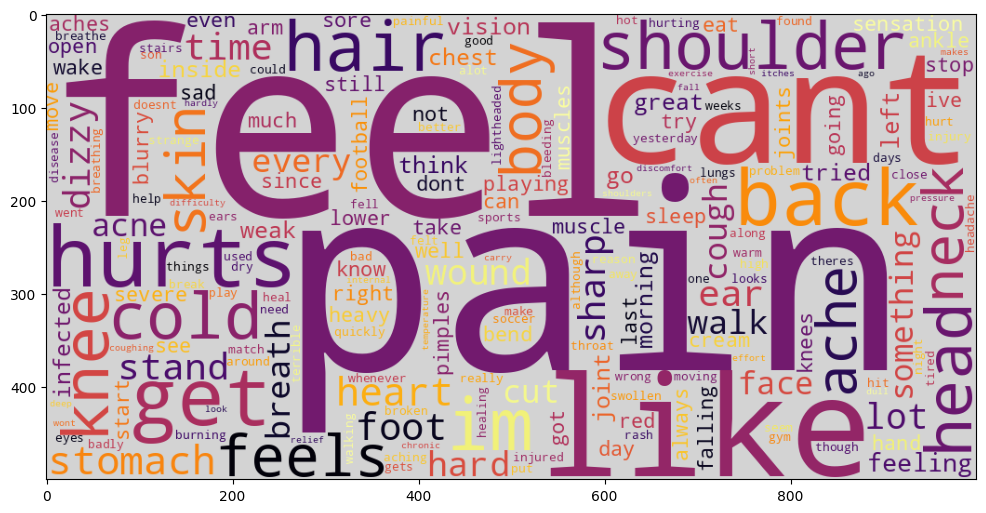

In [104]:
plt.figure(figsize = (12,10))

worldcloud_im = WordCloud(width = 1000, height = 500, background_color = 'lightgray', collocations = False, colormap = 'inferno').generate_from_frequencies(tokens_unique)

plt.imshow(worldcloud_im)
plt.show()

**Análisis de n-gramas**

In [105]:
from sklearn.feature_extraction.text import CountVectorizer

In [106]:
### Crear vectorizador para bigramas y trigramas

vectorizer = CountVectorizer(ngram_range=(2,3))
X = vectorizer.fit_transform(data_clean)

# Convertir a DataFrame con frecuencias
ngrams_freq = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
).sum().sort_values(ascending=False)

print(ngrams_freq.head(10))


in my           1266
pain in          787
pain in my       656
in the           380
on my            358
feel pain        316
feel pain in     250
my head          234
my neck          226
my back          218
dtype: int64
